# TTS 동음이의어 장단음 개선 탐구 (Colab 실행용)

**문제**: '눈(目)'과 '눈ː(雪)', '말(馬)'과 '말ː(言)'처럼 글자는 같아도 소리의 길이가 다른 단어가 있다.
TTS는 글자만 보고 읽기 때문에 이 차이를 거의 반영하지 못한다.

**두 가지 해결 방법**
1. **입력을 바꾸는 방법**: 형태소 분석기(Kiwi)와 Gemini로 장음을 판별한 뒤, 상용 TTS 입력(SSML 또는 철자)에 반영
2. **모델 내부를 바꾸는 방법**: 사전학습 VITS 모델(`facebook/mms-tts-kor`)의 duration 텐서에 hook을 걸어 장음 모음 프레임에 가중치를 곱함

마지막에 두 방법의 음성을 멜 스펙트로그램으로 비교한다.

> 런타임은 CPU로도 충분하다. Gemini API 키는 왼쪽 🔑(보안 비밀)에 `GEMINI_API_KEY`라는 이름으로 넣는다.
> Google Cloud TTS 키(`GOOGLE_TTS_API_KEY`)는 없어도 되며, 없으면 gTTS와 철자 변형으로 대신한다.
> 저장소가 비공개라면 `git clone`이 실패한다. 그때는 GitHub에서 ZIP으로 내려받아 Colab에 올리고 압축을 푼 뒤 `%cd`로 그 폴더에 들어간다.

In [31]:
# 이 셀을 여러 번 실행해도 /content/claude_repo 한 곳만 쓰도록: 처음엔 clone, 그다음부터는 최신 코드로 pull
%cd /content
import os
if os.path.isdir("/content/claude_repo/.git"):
    !git -C /content/claude_repo pull -q
else:
    !git clone -q -b claude/clever-lamport-uucwuo https://github.com/hatnimi/claude_repo.git
%cd /content/claude_repo
!pip -q install -r requirements.txt
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm; fm._load_fontmanager(try_read_cache=False)

/content
You are not currently on a branch.
Please specify which branch you want to merge with.
See git-pull(1) for details.

    git pull <remote> <branch>

/content/claude_repo


In [32]:
import os, sys, json
from google.colab import userdata
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
try:
    os.environ["GOOGLE_TTS_API_KEY"] = userdata.get("GOOGLE_TTS_API_KEY")
except Exception:
    print("Google Cloud TTS 키 없음 → gTTS + 철자 변형 방식으로 진행")
sys.path.insert(0, "src")
from IPython.display import Audio, Image, Markdown, display

## 0단계. Gemini 모델 고르기
아래 첫 셀은 **내 API 키로 쓸 수 있는 Gemini 모델 목록**을 보여 준다.
두 번째 셀의 `GEMINI_MODEL`을 목록에 있는 이름으로 바꾸고 실행한다.

- `503 UNAVAILABLE`(서버 과부하)이 계속 나면 다른 모델로 바꿔 본다. 이름에 `lite`가 들어간 가벼운 모델은 덜 붐비는 경우가 많다.
- 모델을 바꾸면 Gemini에게 처음부터 다시 물어본다. 모델끼리 결과가 섞이지 않게 하기 위해서다.
- 결과 표 제목에 사용한 모델 이름이 기록된다. 면접에서 "어떤 모델로 판별했는지" 말할 때 쓰면 된다.

In [ ]:
from google import genai
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
names = sorted(m.name.removeprefix("models/") for m in client.models.list()
               if "generateContent" in (m.supported_actions or []) and "gemini" in m.name)
print(f"사용 가능한 Gemini 모델 {len(names)}개")
print("\n".join(names))

사용 가능한 Gemini 모델 33개
gemini-2.5-computer-use-preview-10-2025
gemini-2.5-flash
gemini-2.5-flash-image
gemini-2.5-flash-lite
gemini-2.5-flash-preview-tts
gemini-2.5-pro
gemini-2.5-pro-preview-tts
gemini-3-flash-preview
gemini-3-pro-image
gemini-3-pro-image-preview
gemini-3.1-flash-image
gemini-3.1-flash-image-preview
gemini-3.1-flash-lite
gemini-3.1-flash-lite-image
gemini-3.1-flash-lite-preview
gemini-3.1-flash-tts-preview
gemini-3.1-pro-preview
gemini-3.1-pro-preview-customtools
gemini-3.5-flash
gemini-3.5-flash-lite
gemini-3.5-transcribe
gemini-3.6-flash
gemini-3.7-flash
gemini-3.8-flash
gemini-3.8-flash-lite-tts
gemini-3.8-flash-tts
gemini-flash-latest
gemini-flash-lite-latest
gemini-nano-banana-2.1
gemini-omni-1.1-flash
gemini-omni-flash-preview
gemini-pro-latest
gemini-robotics-er-2-preview


In [33]:
os.environ["GEMINI_MODEL"] = "gemini-3.6-flash"   # ← 위 목록에 있는 이름으로 바꾸기

# 고른 모델이 실제로 답하는지 짧게 시험
from google.genai import types
r = client.models.generate_content(model=os.environ["GEMINI_MODEL"], contents="'안녕'이라고만 답해.",
                                   config=types.GenerateContentConfig(temperature=0))
print(f"✅ {os.environ['GEMINI_MODEL']} 응답:", r.text.strip())

✅ gemini-3.6-flash 응답: 안녕


## 1단계. 형태소 분석: 판별 대상 찾기
Kiwi는 '눈이'를 `눈/NNG + 이/JKS`로 나눠 준다. 그래서 조사가 붙어 있어도 명사 '눈'을 정확히 찾을 수 있다.
그러나 두 '눈'은 품사가 똑같이 NNG이므로 **의미는 구별하지 못한다** → 2단계가 필요한 이유.

'첫눈'은 `첫 + 눈`으로 나뉘지만, 어절 중간이라 장음이 될 수 없다(표준 발음법 제6항: 긴소리는 단어의 첫음절에서만 나타난다).

In [ ]:
from morph import get_kiwi, find_candidates
s = "올해 첫눈은 눈이 부시게 하얗게 내렸다."
print([(t.form, t.tag) for t in get_kiwi().tokenize(s)])
for c in find_candidates(s):
    print(c.form, c.start, "어절 첫머리" if c.word_initial else "어절 중간 → 장음 불가", [x["id"] for x in c.senses])

[('올해', 'NNG'), ('첫', 'MM'), ('눈', 'NNG'), ('은', 'JX'), ('눈', 'NNG'), ('이', 'JKS'), ('부시', 'VA'), ('게', 'EC'), ('하얗', 'VA-I'), ('게', 'EC'), ('내리', 'VV'), ('었', 'EP'), ('다', 'EF'), ('.', 'SF')]
눈 4 어절 중간 → 장음 불가 ['눈/目', '눈/雪']
눈 7 어절 첫머리 ['눈/目', '눈/雪']


## 2단계. Gemini로 문맥 판별 + 정확도 평가
- **baseline**: 항상 첫 번째 의미(짧은 소리)를 고른다. 장단을 모르는 일반 TTS와 같은 동작.
- **gemini**: 문장 전체를 보고 의미를 고른다. 평가 문장 12개를 **한 번의 요청으로** 묻는다(서버 과부하에 덜 걸리도록).
  응답 원문은 `outputs/gemini_cache.json`의 `_원본_응답`에 저장된다.

In [ ]:
from disambiguate import build_prompt, evaluate
print(build_prompt(s, find_candidates(s)))   # Gemini에게 실제로 보내는 질문

너는 한국어 표준 발음 전문가야.
아래 문장에서 【번호:단어】로 표시된 단어가 각각 어떤 의미로 쓰였는지 문맥을 보고 골라.

문장: 올해 첫【1:눈】은 【2:눈】이 부시게 하얗게 내렸다.

후보:
1. 눈: "눈/目"(신체 기관(보는 눈)) / "눈/雪"(하늘에서 내리는 눈)
2. 눈: "눈/目"(신체 기관(보는 눈)) / "눈/雪"(하늘에서 내리는 눈)

반드시 아래 JSON 형식으로만 답해.
{"results": [{"index": 번호, "sense_id": "후보 id 그대로", "reason": "한 문장 근거"}]}


In [ ]:
!python run_experiment.py --step disambig
display(Markdown(open("outputs/disambiguation.md", encoding="utf-8").read()))

[gemini] 사용 모델: gemini-3.6-flash
[기본 문장·baseline] 의미 56.0% / 장단 60.0%
[기본 문장·gemini] 의미 100.0% / 장단 100.0%
[어려운 문장·baseline] 의미 45.0% / 장단 55.0%
  Gemini(gemini-3.6-flash)에게 12개 문장을 한 번에 묻는 중...
  (503 서버 과부하 → 15초 기다렸다 다시 시도)
  (503 서버 과부하 → 30초 기다렸다 다시 시도)
[어려운 문장·gemini] 의미 100.0% / 장단 100.0%


# 동음이의어 장단음 판별 결과

# 기본 문장 (12개)

## baseline
- 의미 정확도: 56.0%
- 장단 정확도: 60.0%

| 문장 | 단어 | 정답 | 예측 | 의미 | 장단 | 근거 |
|---|---|---|---|---|---|---|
| 눈에 눈이 들어가서 눈물이 났다. | 눈 | 눈/目 | 눈/目 | O | O | 항상 첫 번째 의미 |
| 눈에 눈이 들어가서 눈물이 났다. | 눈 | 눈/雪 | 눈/目 | X | X | 항상 첫 번째 의미 |
| 올해 첫눈은 눈이 부시게 하얗게 내렸다. | 눈 | 눈/雪 | 눈/目 | X | O | 항상 첫 번째 의미 |
| 올해 첫눈은 눈이 부시게 하얗게 내렸다. | 눈 | 눈/目 | 눈/目 | O | O | 항상 첫 번째 의미 |
| 눈보라가 몰아쳐 눈을 뜰 수 없었다. | 눈보라 | 눈보라 | 눈보라 | O | O | 사전에 의미가 하나뿐 |
| 눈보라가 몰아쳐 눈을 뜰 수 없었다. | 눈 | 눈/目 | 눈/目 | O | O | 항상 첫 번째 의미 |
| 그는 말을 타고 달리면서 계속 말을 걸었다. | 말 | 말/馬 | 말/馬 | O | O | 항상 첫 번째 의미 |
| 그는 말을 타고 달리면서 계속 말을 걸었다. | 말 | 말/言 | 말/馬 | X | X | 항상 첫 번째 의미 |
| 밤에 먹는 밤은 유난히 달다. | 밤 | 밤/夜 | 밤/夜 | O | O | 항상 첫 번째 의미 |
| 밤에 먹는 밤은 유난히 달다. | 밤 | 밤/栗 | 밤/夜 | X | X | 항상 첫 번째 의미 |
| 벌에 쏘였는데 장난친 벌까지 받았다. | 벌 | 벌/蜂 | 벌/罰 | X | X | 항상 첫 번째 의미 |
| 벌에 쏘였는데 장난친 벌까지 받았다. | 벌 | 벌/罰 | 벌/罰 | O | O | 항상 첫 번째 의미 |
| 곰은 굴 속에서 겨울잠을 잤고, 어부는 바다에서 굴을 땄다. | 굴 | 굴/窟 | 굴/石花 | X | X | 항상 첫 번째 의미 |
| 곰은 굴 속에서 겨울잠을 잤고, 어부는 바다에서 굴을 땄다. | 굴 | 굴/石花 | 굴/石花 | O | O | 항상 첫 번째 의미 |
| 창문에 발을 치고 발을 뻗은 채 누웠다. | 발 | 발/簾 | 발/足 | X | X | 항상 첫 번째 의미 |
| 창문에 발을 치고 발을 뻗은 채 누웠다. | 발 | 발/足 | 발/足 | O | O | 항상 첫 번째 의미 |
| 이 배는 저 배보다 두 배나 크다. | 배 | 배/舟 | 배/舟 | O | O | 항상 첫 번째 의미 |
| 이 배는 저 배보다 두 배나 크다. | 배 | 배/舟 | 배/舟 | O | O | 항상 첫 번째 의미 |
| 이 배는 저 배보다 두 배나 크다. | 배 | 배/倍 | 배/舟 | X | X | 항상 첫 번째 의미 |
| 사과를 깎다가 친구에게 사과했다. | 사과 | 사과/沙果 | 사과/沙果 | O | O | 항상 첫 번째 의미 |
| 사과를 깎다가 친구에게 사과했다. | 사과 | 사과/謝過 | 사과/沙果 | X | X | 항상 첫 번째 의미 |
| 아버지와 아들, 두 부자는 마침내 부자가 되었다. | 부자 | 부자/父子 | 부자/父子 | O | O | 항상 첫 번째 의미 |
| 아버지와 아들, 두 부자는 마침내 부자가 되었다. | 부자 | 부자/富者 | 부자/父子 | X | X | 항상 첫 번째 의미 |
| 성인이 되면 성인의 가르침을 읽어 보아라. | 성인 | 성인/成人 | 성인/成人 | O | O | 항상 첫 번째 의미 |
| 성인이 되면 성인의 가르침을 읽어 보아라. | 성인 | 성인/聖人 | 성인/成人 | X | X | 항상 첫 번째 의미 |

## gemini (gemini-3.6-flash)
- 의미 정확도: 100.0%
- 장단 정확도: 100.0%

| 문장 | 단어 | 정답 | 예측 | 의미 | 장단 | 근거 |
|---|---|---|---|---|---|---|
| 눈에 눈이 들어가서 눈물이 났다. | 눈 | 눈/目 | 눈/目 | O | O | 눈물이 나는 대상이 되는 보는 신체 기관을 의미합니다. |
| 눈에 눈이 들어가서 눈물이 났다. | 눈 | 눈/雪 | 눈/雪 | O | O | 신체 기관인 눈에 들어간 하늘에서 내리는 물질을 의미합니다. |
| 올해 첫눈은 눈이 부시게 하얗게 내렸다. | 눈 | 눈/雪 | 눈/雪 | O | O | 올해 첫 번째로 하늘에서 하얗게 내린 눈을 의미합니다. |
| 올해 첫눈은 눈이 부시게 하얗게 내렸다. | 눈 | 눈/目 | 눈/目 | O | O | 하얗게 내린 눈으로 인해 부심을 느끼는 신체 기관을 의미합니다. |
| 눈보라가 몰아쳐 눈을 뜰 수 없었다. | 눈보라 | 눈보라 | 눈보라 | O | O | 사전에 의미가 하나뿐 |
| 눈보라가 몰아쳐 눈을 뜰 수 없었다. | 눈 | 눈/目 | 눈/目 | O | O | 눈보라로 인해 감거나 뜨는 신체 기관을 의미합니다. |
| 그는 말을 타고 달리면서 계속 말을 걸었다. | 말 | 말/馬 | 말/馬 | O | O | 사람이 타고 달리는 동물을 의미합니다. |
| 그는 말을 타고 달리면서 계속 말을 걸었다. | 말 | 말/言 | 말/言 | O | O | 타인에게 거는 사람이 하는 언어 표현을 의미합니다. |
| 밤에 먹는 밤은 유난히 달다. | 밤 | 밤/夜 | 밤/夜 | O | O | 해가 진 뒤 음식이나 음료를 먹는 시간대를 의미합니다. |
| 밤에 먹는 밤은 유난히 달다. | 밤 | 밤/栗 | 밤/栗 | O | O | 맛이 달다고 표현된 먹는 밤나무의 열매를 의미합니다. |
| 벌에 쏘였는데 장난친 벌까지 받았다. | 벌 | 벌/蜂 | 벌/蜂 | O | O | 사람을 쏘는 주체인 곤충을 의미합니다. |
| 벌에 쏘였는데 장난친 벌까지 받았다. | 벌 | 벌/罰 | 벌/罰 | O | O | 장난을 친 행동에 대해 받는 처벌을 의미합니다. |
| 곰은 굴 속에서 겨울잠을 잤고, 어부는 바다에서 굴을 땄다. | 굴 | 굴/窟 | 굴/窟 | O | O | 곰이 들어가 겨울잠을 자는 땅이나 바위의 구멍을 의미합니다. |
| 곰은 굴 속에서 겨울잠을 잤고, 어부는 바다에서 굴을 땄다. | 굴 | 굴/石花 | 굴/石花 | O | O | 어부가 바다에서 따는 먹는 조개류를 의미합니다. |
| 창문에 발을 치고 발을 뻗은 채 누웠다. | 발 | 발/簾 | 발/簾 | O | O | 창문에 드리우거나 치는 햇빛 가림막을 의미합니다. |
| 창문에 발을 치고 발을 뻗은 채 누웠다. | 발 | 발/足 | 발/足 | O | O | 누워서 뻗는 신체 부위를 의미합니다. |
| 이 배는 저 배보다 두 배나 크다. | 배 | 배/舟 | 배/舟 | O | O | 크기를 서로 비교하고 있는 탈것을 의미합니다. |
| 이 배는 저 배보다 두 배나 크다. | 배 | 배/舟 | 배/舟 | O | O | 비교의 대상이 되는 다른 탈것을 의미합니다. |
| 이 배는 저 배보다 두 배나 크다. | 배 | 배/倍 | 배/倍 | O | O | 크기의 수량적 곱절(두 배)을 나타냅니다. |
| 사과를 깎다가 친구에게 사과했다. | 사과 | 사과/沙果 | 사과/沙果 | O | O | 칼 등으로 깎아 먹는 과일을 의미합니다. |
| 사과를 깎다가 친구에게 사과했다. | 사과 | 사과/謝過 | 사과/謝過 | O | O | 친구에게 자신의 잘못이나 실수를 빎을 의미합니다. |
| 아버지와 아들, 두 부자는 마침내 부자가 되었다. | 부자 | 부자/父子 | 부자/父子 | O | O | 앞서 언급된 아버지와 아들 관계를 가리킵니다. |
| 아버지와 아들, 두 부자는 마침내 부자가 되었다. | 부자 | 부자/富者 | 부자/富者 | O | O | 재산을 많이 모아 넉넉해진 사람을 의미합니다. |
| 성인이 되면 성인의 가르침을 읽어 보아라. | 성인 | 성인/成人 | 성인/成人 | O | O | 자라서 법적으로나 사회적으로 어른이 된 사람을 의미합니다. |
| 성인이 되면 성인의 가르침을 읽어 보아라. | 성인 | 성인/聖人 | 성인/聖人 | O | O | 가르침을 남긴 뛰어난 지혜와 덕을 지닌 사람을 의미합니다. |

# 어려운 문장 (12개)

## baseline
- 의미 정확도: 45.0%
- 장단 정확도: 55.0%

| 문장 | 단어 | 정답 | 예측 | 의미 | 장단 | 근거 | 함정 |
|---|---|---|---|---|---|---|---|
| 햇빛에 반사된 눈 때문에 눈이 부셨다. | 눈 | 눈/雪 | 눈/目 | X | X | 항상 첫 번째 의미 | 두 '눈' 모두 빛·부심과 연결돼 단서가 겹친다 |
| 햇빛에 반사된 눈 때문에 눈이 부셨다. | 눈 | 눈/目 | 눈/目 | O | O | 항상 첫 번째 의미 | 두 '눈' 모두 빛·부심과 연결돼 단서가 겹친다 |
| 경마장에서 그는 내 말은 듣지도 않고 자기 말만 응원했다. | 말 | 말/言 | 말/馬 | X | X | 항상 첫 번째 의미 | '내 말'과 '자기 말'의 문장 구조가 똑같다 |
| 경마장에서 그는 내 말은 듣지도 않고 자기 말만 응원했다. | 말 | 말/馬 | 말/馬 | O | O | 항상 첫 번째 의미 | '내 말'과 '자기 말'의 문장 구조가 똑같다 |
| 배가 고픈 선원은 배 위에서 배를 깎아 먹었다. | 배 | 배/腹 | 배/舟 | X | O | 항상 첫 번째 의미 | 한 문장에 세 가지 '배'(모두 짧은 소리) |
| 배가 고픈 선원은 배 위에서 배를 깎아 먹었다. | 배 | 배/舟 | 배/舟 | O | O | 항상 첫 번째 의미 | 한 문장에 세 가지 '배'(모두 짧은 소리) |
| 배가 고픈 선원은 배 위에서 배를 깎아 먹었다. | 배 | 배/梨 | 배/舟 | X | O | 항상 첫 번째 의미 | 한 문장에 세 가지 '배'(모두 짧은 소리) |
| 작년보다 쌀값이 배로 올랐다. | 배 | 배/倍 | 배/舟 | X | X | 항상 첫 번째 의미 | '두 배' 같은 숫자 단서 없이 '배로'만으로 곱절을 뜻함 |
| 긴 밤 내내 화롯불에 밤을 구웠다. | 밤 | 밤/夜 | 밤/夜 | O | O | 항상 첫 번째 의미 | '긴 밤'의 '긴'이 장음처럼 들리는 함정 |
| 긴 밤 내내 화롯불에 밤을 구웠다. | 밤 | 밤/栗 | 밤/夜 | X | X | 항상 첫 번째 의미 | '긴 밤'의 '긴'이 장음처럼 들리는 함정 |
| 그는 벌을 받는 대신 벌을 치는 일을 맡았다. | 벌 | 벌/罰 | 벌/罰 | O | O | 항상 첫 번째 의미 | '벌을 치다'(벌을 기르다)라는 관용 표현을 알아야 함 |
| 그는 벌을 받는 대신 벌을 치는 일을 맡았다. | 벌 | 벌/蜂 | 벌/罰 | X | X | 항상 첫 번째 의미 | '벌을 치다'(벌을 기르다)라는 관용 표현을 알아야 함 |
| 발이 시려서 발을 걷고 햇볕을 쬐었다. | 발 | 발/足 | 발/足 | O | O | 항상 첫 번째 의미 | '발을 걷다'(가림막을 말아 올리다)를 '걷다(walk)'로 착각하기 쉬움 |
| 발이 시려서 발을 걷고 햇볕을 쬐었다. | 발 | 발/簾 | 발/足 | X | X | 항상 첫 번째 의미 | '발을 걷다'(가림막을 말아 올리다)를 '걷다(walk)'로 착각하기 쉬움 |
| 그 집 부자는 얼굴이 꼭 닮았다. | 부자 | 부자/父子 | 부자/父子 | O | O | 항상 첫 번째 의미 | '닮았다'는 두 사람이 필요하다는 점에서 추론해야 함 |
| 그는 끝내 내 사과를 받아 주지 않았다. | 사과 | 사과/謝過 | 사과/沙果 | X | X | 항상 첫 번째 의미 | '사과를 받다'는 과일로도 말이 됨. '받아 주지 않았다'에서 추론 |
| 그 노인은 마을 사람들에게 성인으로 존경받았다. | 성인 | 성인/聖人 | 성인/成人 | X | X | 항상 첫 번째 의미 | 노인은 당연히 어른(成人)이라 '존경'에서 추론해야 함 |
| 갯벌에서 굴을 캐다가 소나기가 쏟아져 바위 굴로 피했다. | 굴 | 굴/石花 | 굴/石花 | O | O | 항상 첫 번째 의미 | 둘 다 바닷가 바위와 관련된 장소에서 등장 |
| 갯벌에서 굴을 캐다가 소나기가 쏟아져 바위 굴로 피했다. | 굴 | 굴/窟 | 굴/石花 | X | X | 항상 첫 번째 의미 | 둘 다 바닷가 바위와 관련된 장소에서 등장 |
| 함박눈이 내린 날, 그는 눈을 감고 소원을 빌었다. | 눈 | 눈/目 | 눈/目 | O | O | 항상 첫 번째 의미 | 앞에 '함박눈'(雪)이 있어 雪로 끌려가기 쉬움 |

## gemini (gemini-3.6-flash)
- 의미 정확도: 100.0%
- 장단 정확도: 100.0%

| 문장 | 단어 | 정답 | 예측 | 의미 | 장단 | 근거 | 함정 |
|---|---|---|---|---|---|---|---|
| 햇빛에 반사된 눈 때문에 눈이 부셨다. | 눈 | 눈/雪 | 눈/雪 | O | O | 햇빛에 반사되어 빛을 반사하는 지상의 눈(雪)을 의미합니다. | 두 '눈' 모두 빛·부심과 연결돼 단서가 겹친다 |
| 햇빛에 반사된 눈 때문에 눈이 부셨다. | 눈 | 눈/目 | 눈/目 | O | O | 빛을 받아 부심을 느끼는 신체 감각 기관을 의미합니다. | 두 '눈' 모두 빛·부심과 연결돼 단서가 겹친다 |
| 경마장에서 그는 내 말은 듣지도 않고 자기 말만 응원했다. | 말 | 말/言 | 말/言 | O | O | 사람이 입으로 하여 타인에게 전달하는 언어를 의미합니다. | '내 말'과 '자기 말'의 문장 구조가 똑같다 |
| 경마장에서 그는 내 말은 듣지도 않고 자기 말만 응원했다. | 말 | 말/馬 | 말/馬 | O | O | 경마장에서 경주하는 동물 말을 의미합니다. | '내 말'과 '자기 말'의 문장 구조가 똑같다 |
| 배가 고픈 선원은 배 위에서 배를 깎아 먹었다. | 배 | 배/腹 | 배/腹 | O | O | 고픔을 느끼는 신체 부위를 의미합니다. | 한 문장에 세 가지 '배'(모두 짧은 소리) |
| 배가 고픈 선원은 배 위에서 배를 깎아 먹었다. | 배 | 배/舟 | 배/舟 | O | O | 선원이 타고 있는 물 위를 다니는 탈것을 의미합니다. | 한 문장에 세 가지 '배'(모두 짧은 소리) |
| 배가 고픈 선원은 배 위에서 배를 깎아 먹었다. | 배 | 배/梨 | 배/梨 | O | O | 껍질을 깎아서 먹는 과일을 의미합니다. | 한 문장에 세 가지 '배'(모두 짧은 소리) |
| 작년보다 쌀값이 배로 올랐다. | 배 | 배/倍 | 배/倍 | O | O | 가격이 두 배로 늘어났음을 나타내는 곱절의 의미입니다. | '두 배' 같은 숫자 단서 없이 '배로'만으로 곱절을 뜻함 |
| 긴 밤 내내 화롯불에 밤을 구웠다. | 밤 | 밤/夜 | 밤/夜 | O | O | 해가 진 뒤부터 다음 날 해가 뜨기 전까지의 시간을 의미합니다. | '긴 밤'의 '긴'이 장음처럼 들리는 함정 |
| 긴 밤 내내 화롯불에 밤을 구웠다. | 밤 | 밤/栗 | 밤/栗 | O | O | 화롯불에 구워 먹는 밤나무의 열매를 의미합니다. | '긴 밤'의 '긴'이 장음처럼 들리는 함정 |
| 그는 벌을 받는 대신 벌을 치는 일을 맡았다. | 벌 | 벌/罰 | 벌/罰 | O | O | 잘못을 저질러 받게 되는 처벌을 의미합니다. | '벌을 치다'(벌을 기르다)라는 관용 표현을 알아야 함 |
| 그는 벌을 받는 대신 벌을 치는 일을 맡았다. | 벌 | 벌/蜂 | 벌/蜂 | O | O | 꿀을 얻거나 기르기 위해 치는 곤충을 의미합니다. | '벌을 치다'(벌을 기르다)라는 관용 표현을 알아야 함 |
| 발이 시려서 발을 걷고 햇볕을 쬐었다. | 발 | 발/足 | 발/足 | O | O | 추위로 인해 시려움을 느끼는 신체 부위를 의미합니다. | '발을 걷다'(가림막을 말아 올리다)를 '걷다(walk)'로 착각하기 쉬움 |
| 발이 시려서 발을 걷고 햇볕을 쬐었다. | 발 | 발/簾 | 발/簾 | O | O | 햇빛을 가리기 위해 쳐 놓은 가림막을 의미합니다. | '발을 걷다'(가림막을 말아 올리다)를 '걷다(walk)'로 착각하기 쉬움 |
| 그 집 부자는 얼굴이 꼭 닮았다. | 부자 | 부자/父子 | 부자/父子 | O | O | 얼굴이 닮았다는 문맥에서 아버지와 아들 관계를 의미합니다. | '닮았다'는 두 사람이 필요하다는 점에서 추론해야 함 |
| 그는 끝내 내 사과를 받아 주지 않았다. | 사과 | 사과/謝過 | 사과/謝過 | O | O | 잘못을 빌고 용서를 구하는 행위를 의미합니다. | '사과를 받다'는 과일로도 말이 됨. '받아 주지 않았다'에서 추론 |
| 그 노인은 마을 사람들에게 성인으로 존경받았다. | 성인 | 성인/聖人 | 성인/聖人 | O | O | 마을 사람들에게 존경받는 지혜롭고 덕이 높은 사람을 의미합니다. | 노인은 당연히 어른(成人)이라 '존경'에서 추론해야 함 |
| 갯벌에서 굴을 캐다가 소나기가 쏟아져 바위 굴로 피했다. | 굴 | 굴/石花 | 굴/石花 | O | O | 갯벌에서 채취하여 먹는 조개류를 의미합니다. | 둘 다 바닷가 바위와 관련된 장소에서 등장 |
| 갯벌에서 굴을 캐다가 소나기가 쏟아져 바위 굴로 피했다. | 굴 | 굴/窟 | 굴/窟 | O | O | 비바람을 피하기 위해 들어간 바위 구멍을 의미합니다. | 둘 다 바닷가 바위와 관련된 장소에서 등장 |
| 함박눈이 내린 날, 그는 눈을 감고 소원을 빌었다. | 눈 | 눈/目 | 눈/目 | O | O | 소원을 빌 때 감는 신체 기관을 의미합니다. | 앞에 '함박눈'(雪)이 있어 雪로 끌려가기 쉬움 |


## 3단계-① 방법 1: 상용 TTS의 입력 바꾸기

  ⚠️ Google Cloud TTS 403: Requests to this API texttospeech.googleapis.com method google.cloud.texttospeech.v1.TextToSpeech.SynthesizeSpeech are blocked.
  → Google Cloud TTS를 쓸 수 없어 gTTS + 철자 변형으로 대신합니다.
[상용 TTS] 눈에 눈이 들어가서 눈물이 났다.  →  눈에 누운이 들어가서 눈물이 났다.
[상용 TTS] 그는 말을 타고 달리면서 계속 말을 걸었다.  →  그는 말을 타고 달리면서 계속 마알을 걸었다.
[상용 TTS] 밤에 먹는 밤은 유난히 달다.  →  밤에 먹는 바암은 유난히 달다.
[상용 TTS] 사과를 깎다가 친구에게 사과했다.  →  사과를 깎다가 친구에게 사아과했다.


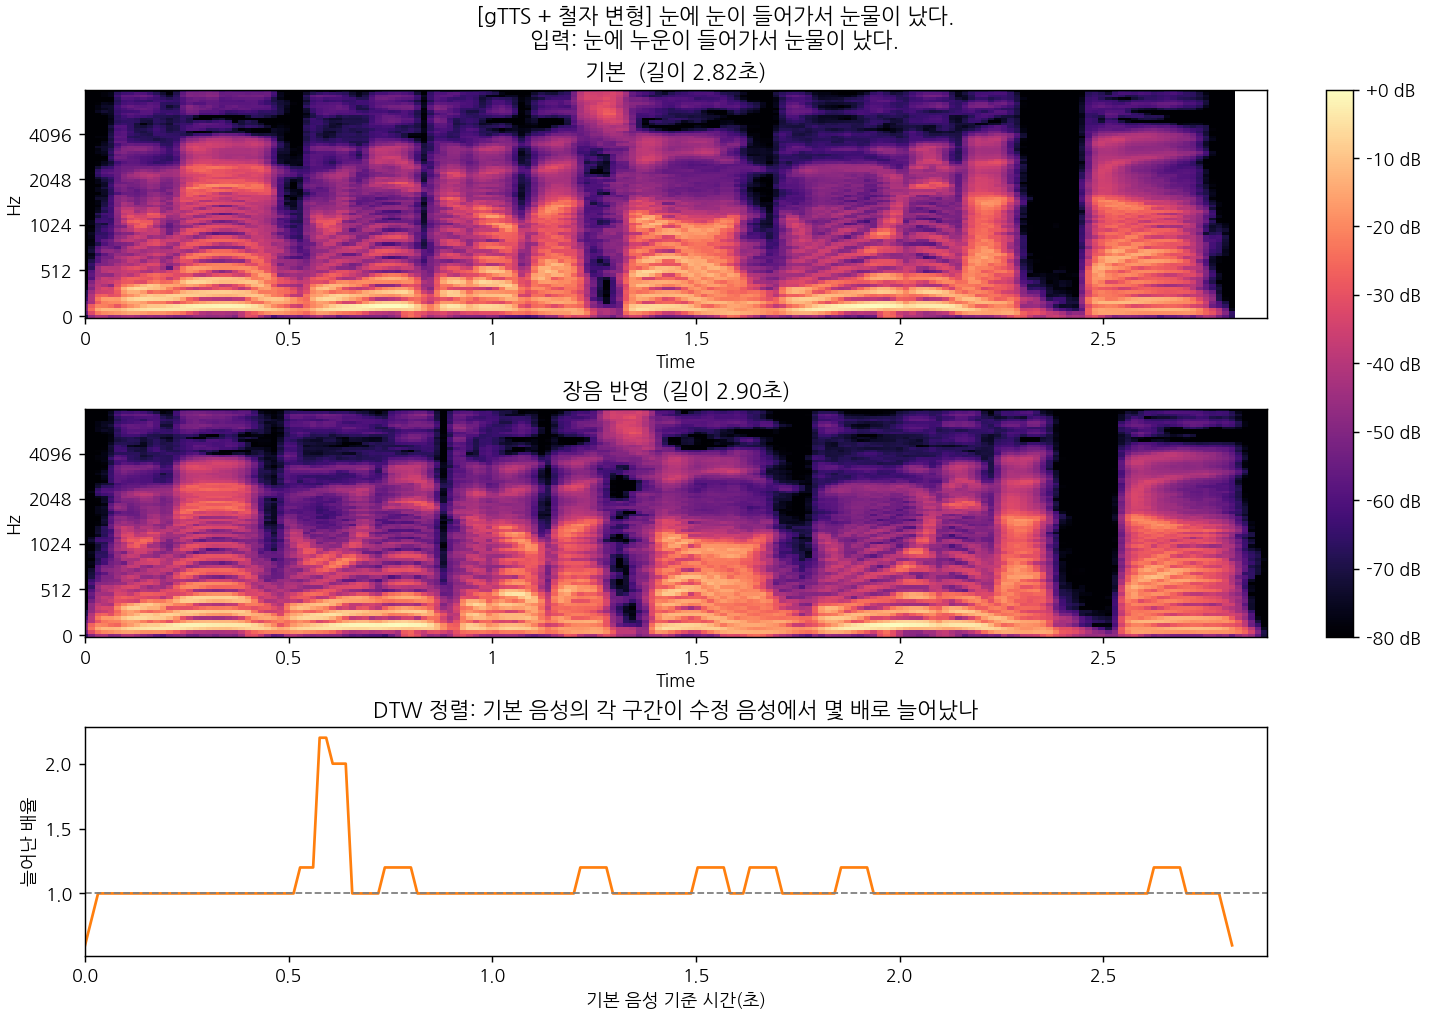

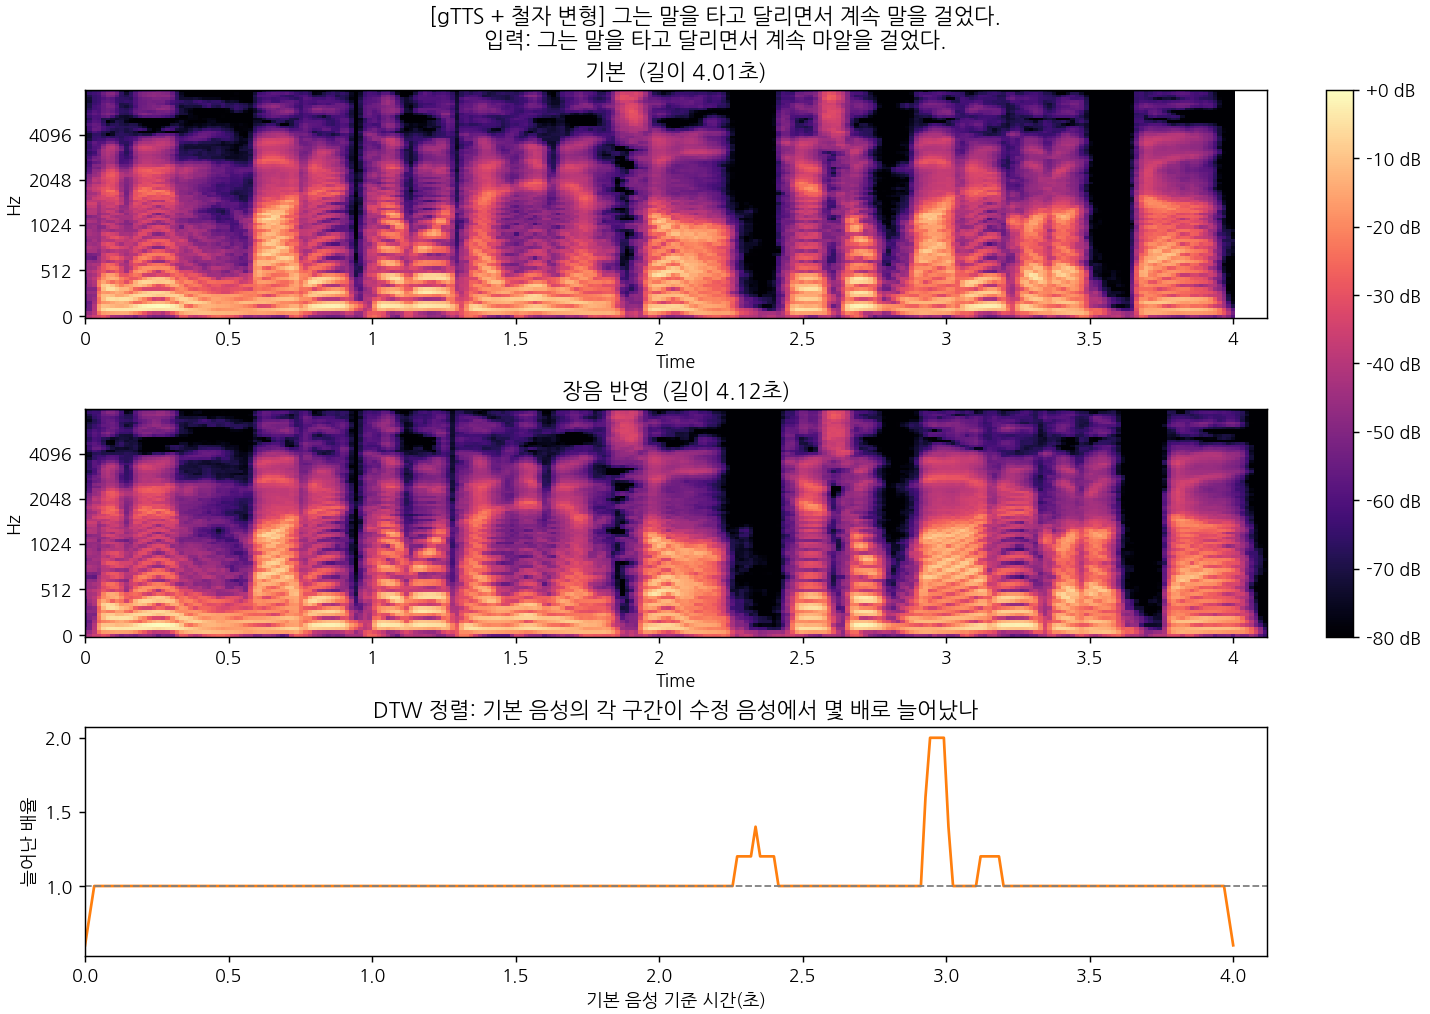

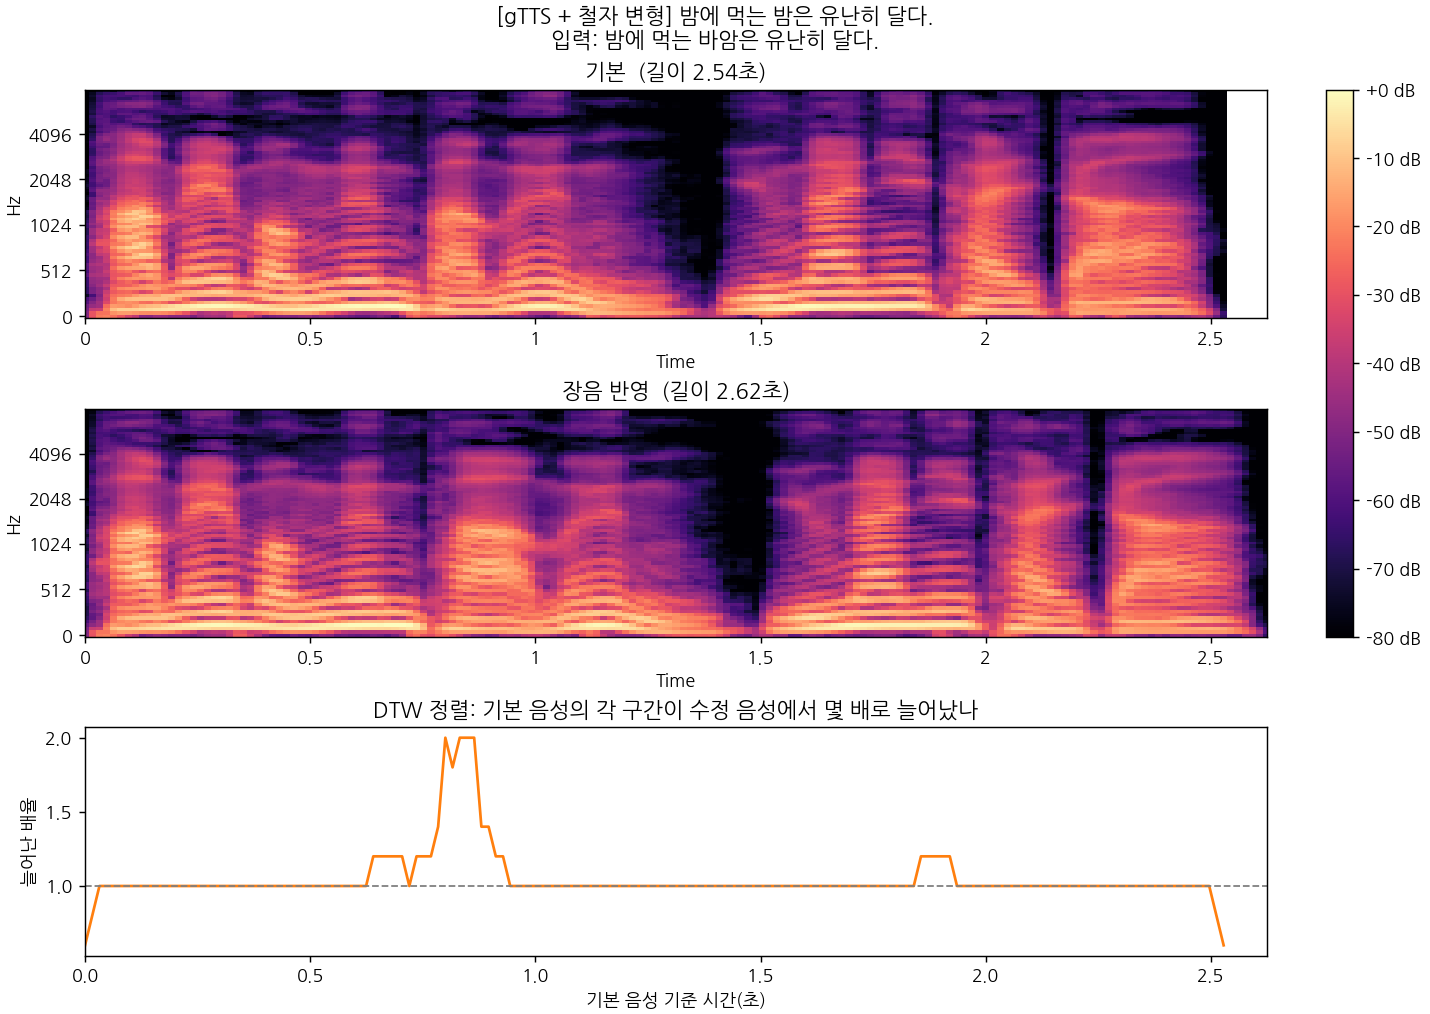

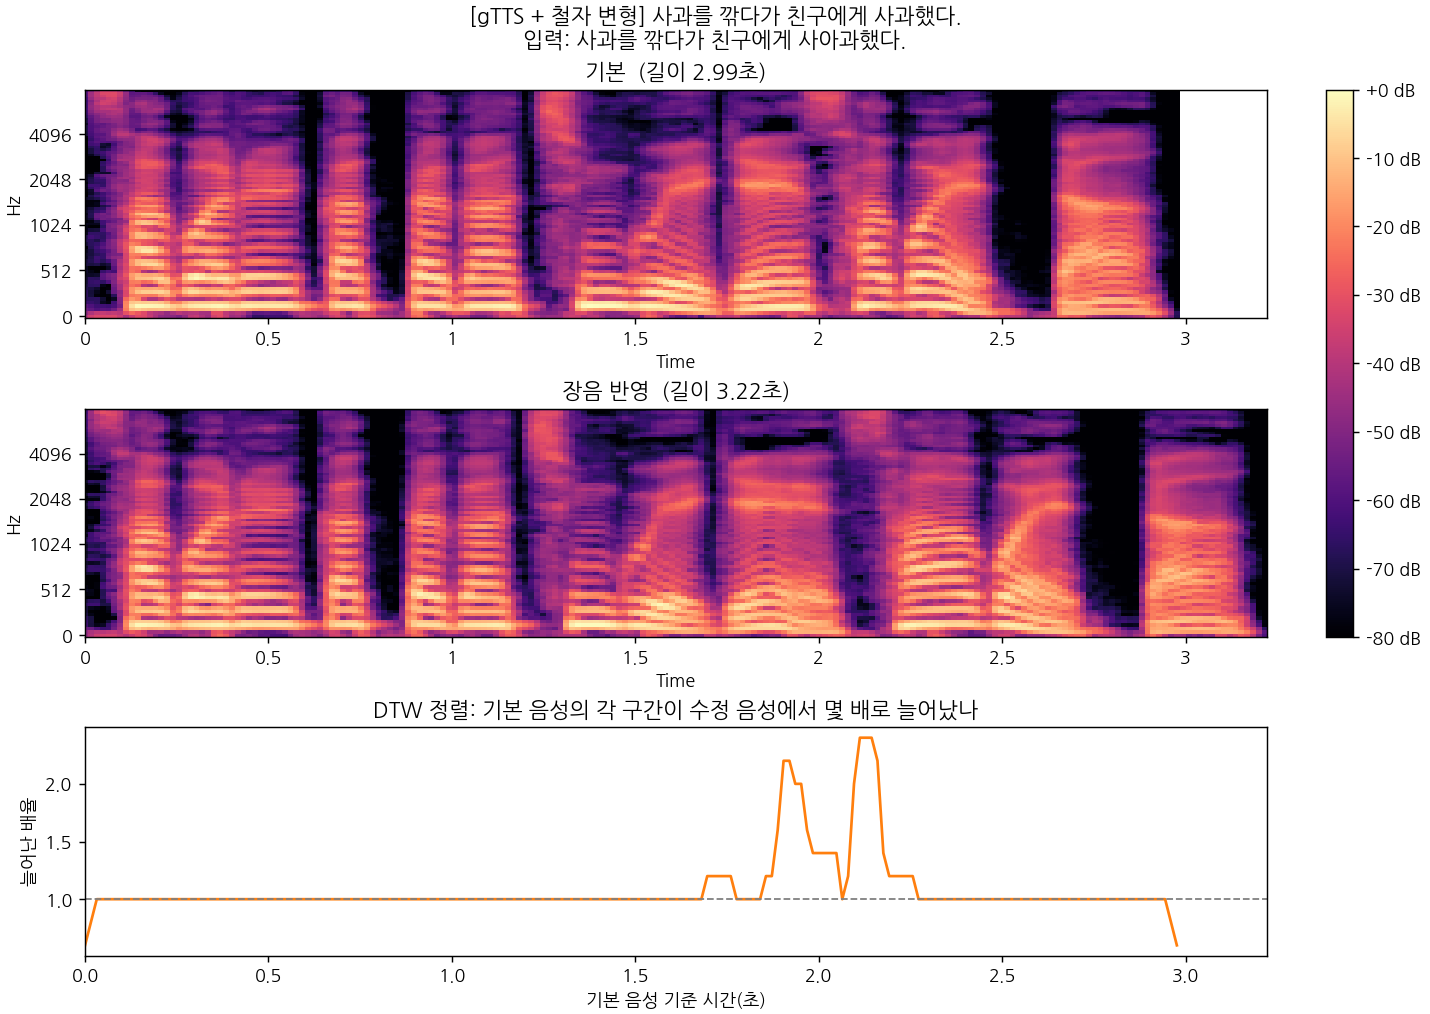

In [34]:
!python run_experiment.py --step commercial
import os
for i in range(4):
    if not os.path.exists(f"outputs/commercial/{i}_mel.png"):
        print(f"⚠️ {i}번 문장 결과가 없습니다. 위의 실행 메시지를 확인하세요."); continue
    display(Image(f"outputs/commercial/{i}_mel.png"))
    display(Audio(f"outputs/commercial/{i}_base.wav")); display(Audio(f"outputs/commercial/{i}_mod.wav"))

## 3단계-② 방법 2: VITS 모델의 duration 텐서에 직접 개입
`model.duration_predictor`의 출력(log_duration, 모양 `(1, 1, 토큰 수)`)에 forward hook을 건다.
장음 모음 토큰 위치에만 `log(w)`를 더하면 `exp`를 거친 뒤 그 토큰의 프레임 수만 `w`배가 된다.

In [35]:
from approach2_vits import VowelLengthVITS
from disambiguate import disambiguate
tts = VowelLengthVITS()
text = "눈에 눈이 들어가서 눈물이 났다."
cands = disambiguate(text)
base = tts.synthesize(text, cands, weight=1.0)
mod  = tts.synthesize(text, cands, weight=1.8)
print("로마자 입력:", mod["roman"])
print("개입한 토큰 위치:", mod["targets"])
tok = tts.tokenizer.convert_ids_to_tokens(tts.token_layout(text)[2][0])
for k in range(len(tok)):
    mark = "  ← 장음" if k in mod["targets"] else ""
    print(f"{k:3d} {tok[k]!r:6} {base['frames'][k]:3d} → {mod['frames'][k]:3d} 프레임{mark}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.64k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/286 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/268 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/145M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/762 [00:00<?, ?it/s]

로마자 입력: nune nuni deuleogaseo nunmuli nassda
개입한 토큰 위치: [13, 14]
  0 'u'     32 →  32 프레임
  1 'n'      3 →   3 프레임
  2 'u'      5 →   5 프레임
  3 'u'      2 →   2 프레임
  4 'u'      4 →   4 프레임
  5 'n'      2 →   2 프레임
  6 'u'      2 →   2 프레임
  7 'e'      1 →   1 프레임
  8 'u'      6 →   6 프레임
  9 ' '      1 →   1 프레임
 10 'u'      1 →   1 프레임
 11 'n'      4 →   4 프레임
 12 'u'      2 →   2 프레임
 13 'u'      2 →   3 프레임  ← 장음
 14 'u'      4 →   7 프레임  ← 장음
 15 'n'      1 →   1 프레임
 16 'u'      2 →   2 프레임
 17 'i'      1 →   1 프레임
 18 'u'      3 →   3 프레임
 19 ' '      1 →   1 프레임
 20 'u'      2 →   2 프레임
 21 'd'      1 →   1 프레임
 22 'u'      1 →   1 프레임
 23 'e'      2 →   2 프레임
 24 'u'      2 →   2 프레임
 25 'u'      1 →   1 프레임
 26 'u'      1 →   1 프레임
 27 'l'      1 →   1 프레임
 28 'u'      1 →   1 프레임
 29 'e'      2 →   2 프레임
 30 'u'      1 →   1 프레임
 31 'o'      1 →   1 프레임
 32 'u'      1 →   1 프레임
 33 'g'      1 →   1 프레임
 34 'u'      1 →   1 프레임
 35 'a'      1 →   1 프레임
 36 'u'      2 →   2 프레

Loading weights: 100% 762/762 [00:00<00:00, 13225.82it/s]
[VITS] 눈에 눈이 들어가서 눈물이 났다.  로마자: nune nuni deuleogaseo nunmuli nassda  개입 토큰: [13, 14]
[VITS] 그는 말을 타고 달리면서 계속 말을 걸었다.  로마자: geuneun maleul tago dalrimyeonseo gyesog maleul geoleossda  개입 토큰: [85, 86]
[VITS] 밤에 먹는 밤은 유난히 달다.  로마자: bame meogneun bameun yunanhi dalda  개입 토큰: [31, 32]
[VITS] 사과를 깎다가 친구에게 사과했다.  로마자: sagwareul ggaggdaga cinguege sagwahaessda  개입 토큰: [61, 62]


# VITS duration 개입 결과

| 문장 | 음절 | 기본(ms) | 개입 후(ms) | 배율 |
|---|---|---|---|---|
| 눈에 눈이 들어가서 눈물이 났다. | 눈 | 240 | 304 | 1.27 |
| 그는 말을 타고 달리면서 계속 말을 걸었다. | 말 | 144 | 176 | 1.22 |
| 밤에 먹는 밤은 유난히 달다. | 밤 | 208 | 240 | 1.15 |
| 사과를 깎다가 친구에게 사과했다. | 사 | 160 | 208 | 1.3 |

## 가중치 탐색

| 가중치 | 장음 음절 길이(ms) | 전체 길이(초) |
|---|---|---|
| 1.0 | 240 | 3.33 |
| 1.25 | 256 | 3.34 |
| 1.5 | 288 | 3.38 |
| 1.75 | 304 | 3.39 |
| 2.0 | 336 | 3.42 |
| 2.5 | 352 | 3.44 |
| 3.0 | 400 | 3.49 |


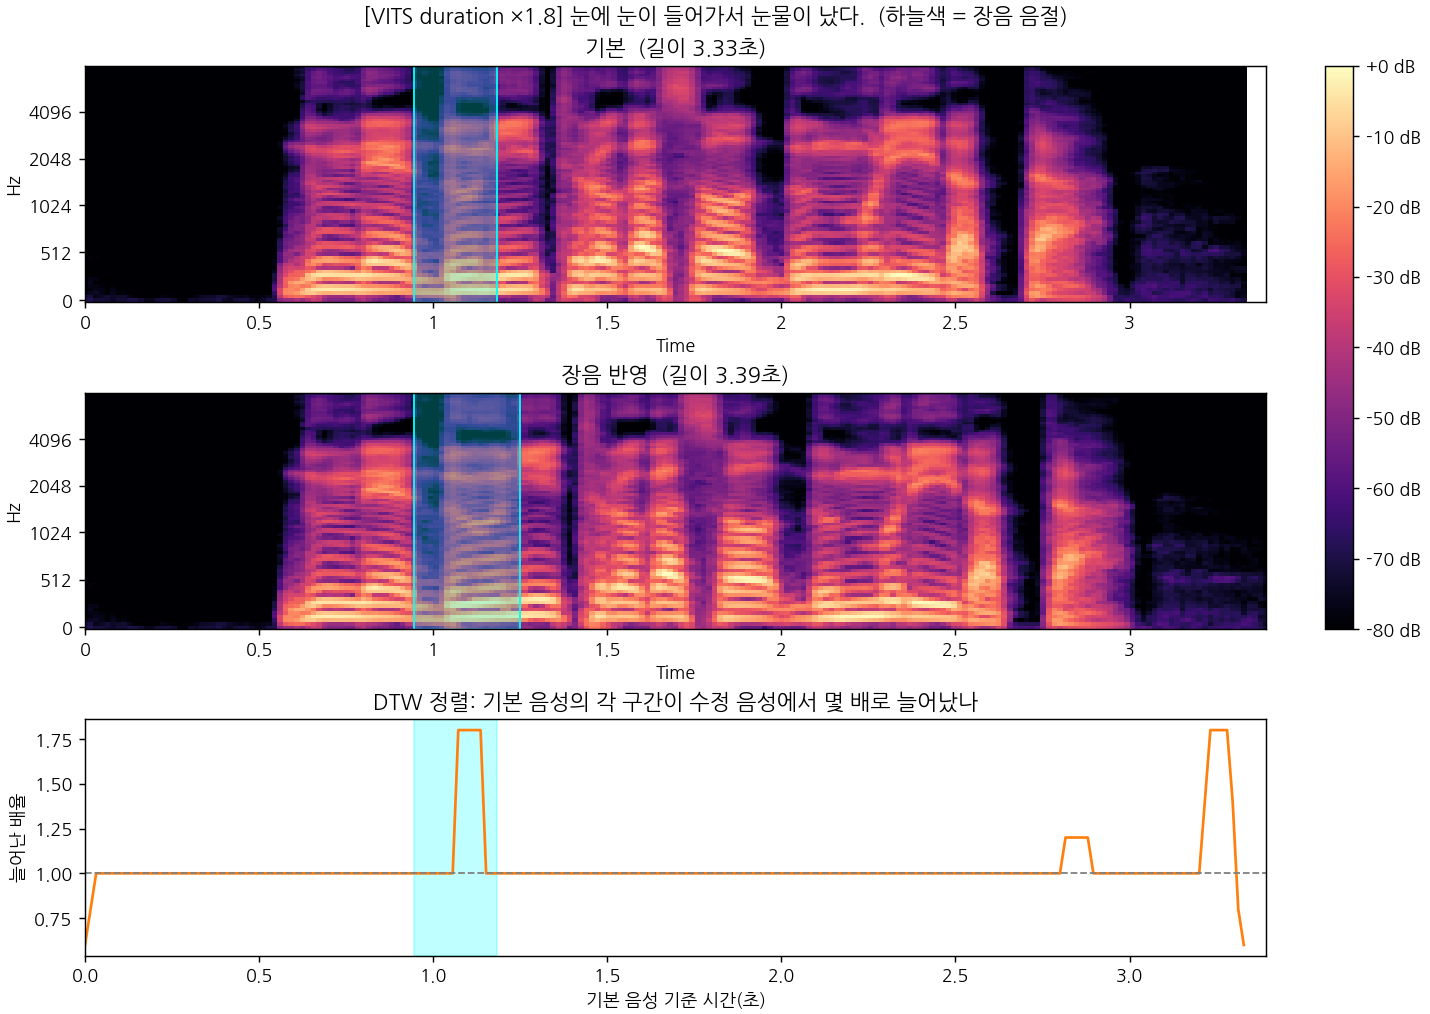

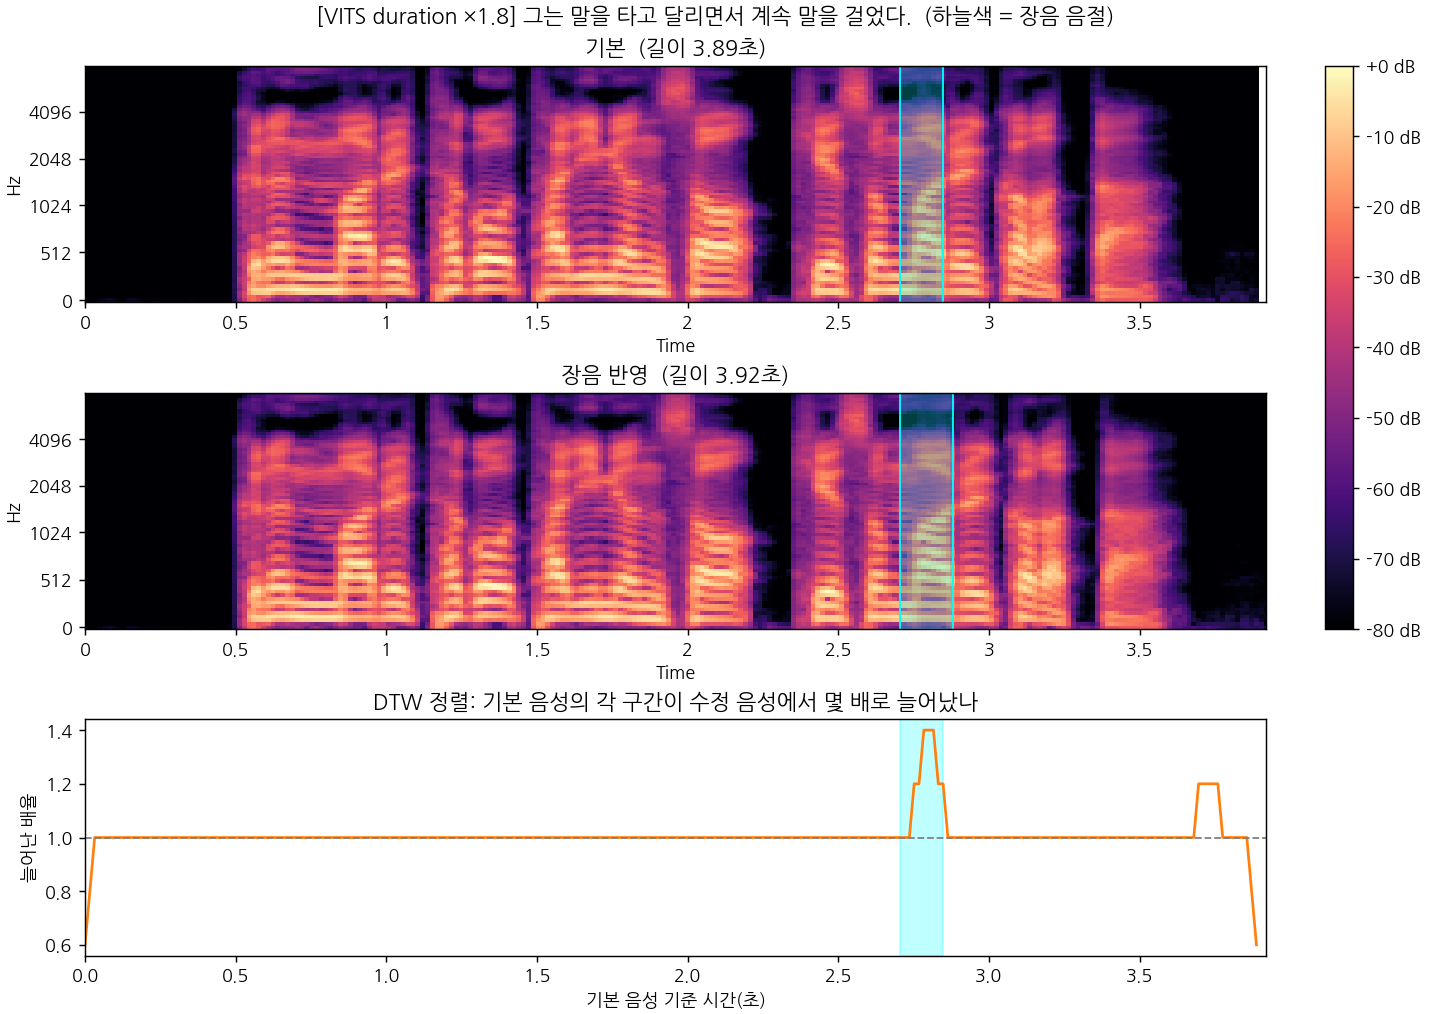

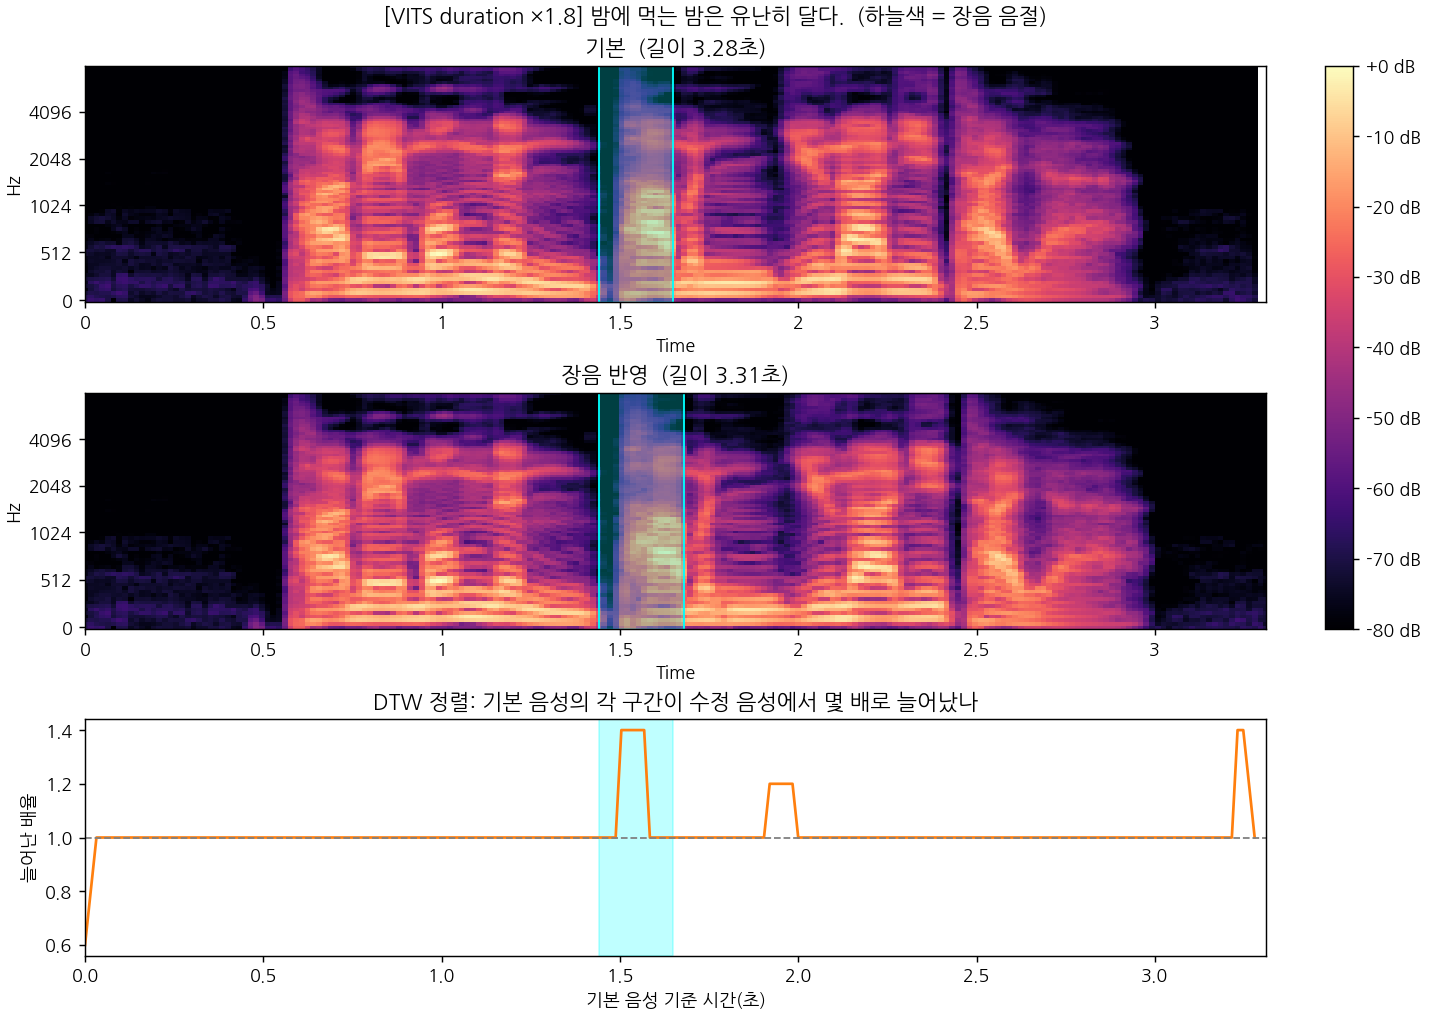

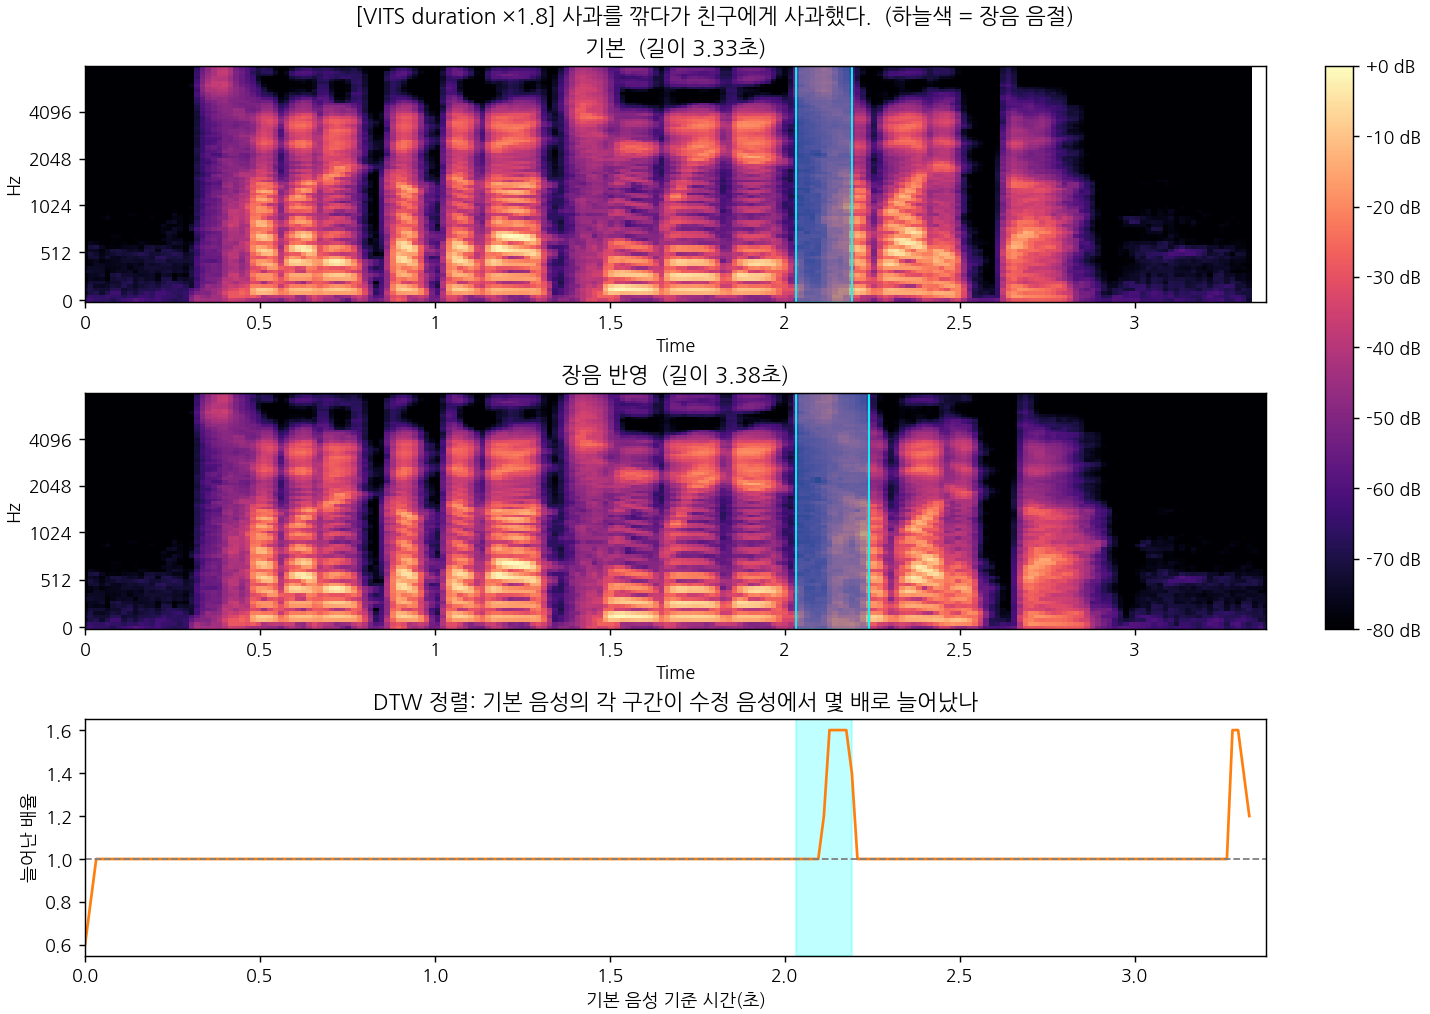

In [36]:
!python run_experiment.py --step vits --weight 1.8
display(Markdown(open("outputs/vits_result.md", encoding="utf-8").read()))
for i in range(4):
    display(Image(f"outputs/vits/{i}_mel.png"))
    display(Audio(f"outputs/vits/{i}_base.wav")); display(Audio(f"outputs/vits/{i}_mod.wav"))

## 4단계. 가중치 탐색: 몇 배가 가장 자연스러운가?
직접 들어 보고 `docs/탐구노트.md`에 느낀 점을 기록하자.

In [37]:
for w in [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]:
    print("가중치", w); display(Audio(f"outputs/vits/sweep_w{w}.wav"))

가중치 1.0


가중치 1.25


가중치 1.5


가중치 1.75


가중치 2.0


가중치 2.5


가중치 3.0


## 💾 GitHub에 저장하기 (Colab의 'GitHub에 사본 저장' 대신)
이 셀은 **지금 화면의 노트북(실행 결과 포함)**, `outputs/` 결과 파일을 GitHub에 커밋하고 올린다.

처음 한 번만 준비한다.
1. GitHub → 프로필 사진 → **Settings** → 맨 아래 **Developer settings** → **Personal access tokens** → **Fine-grained tokens** → **Generate new token**
2. Repository access는 **Only select repositories** → `claude_repo`, Permissions → Repository permissions → **Contents: Read and write**
3. 만든 토큰을 복사해서 Colab 🔑 보안 비밀에 이름 `GITHUB_TOKEN`으로 저장하고, **노트북 액세스**를 켠다.

작업하다가 저장하고 싶을 때마다 이 셀만 실행하면 된다.

In [39]:
import sys; sys.path.insert(0, "/content/claude_repo/src")
import importlib, save_to_github; importlib.reload(save_to_github)
save_to_github.save(message="Colab에서 실행 결과 저장")   # 커밋 메시지는 바꿔도 된다




[detached HEAD f50c1ac] Colab에서 실행 결과 저장
 1 file changed, 27 insertions(+), 27 deletions(-)
From https://github.com/hatnimi/claude_repo
 * branch            claude/clever-lamport-uucwuo -> FETCH_HEAD
fatal: It seems that there is already a rebase-merge directory, and
I wonder if you are in the middle of another rebase.  If that is the
case, please try
	git rebase (--continue | --abort | --skip)
If that is not the case, please
	rm -fr ".git/rebase-merge"
and run me again.  I am stopping in case you still have something
valuable there.
To https://github.com/hatnimi/claude_repo.git
 ! [rejected]        HEAD -> claude/clever-lamport-uucwuo (non-fast-forward)
error: failed to push some refs to 'https://github.com/hatnimi/claude_repo.git'
hint: Updates were rejected because a pushed branch tip is behind its remote
hint: counterpart. If you want to integrate the remote changes, use 'git pull'
hint: before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for deta

In [ ]:
import subprocess, sys
R = "/content/claude_repo"
subprocess.run(["git", "-C", R, "fetch", "-q", "origin", "claude/clever-lamport-uucwuo"])
subprocess.run(["git", "-C", R, "checkout", "FETCH_HEAD", "--", "src/save_to_github.py"])
sys.path.insert(0, R + "/src")
import save_to_github
save_to_github.save()